# Chapter2 NumPy与数组操作

## 2.1 数组形状变换函数

### 2.1.1 np.reshape

In [1]:
import numpy as np

In [2]:
a = np.arange(12)

In [3]:
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [4]:
b = np.reshape(a, (3, 4)) # 变形为3×4的二维数组

In [5]:
b # 确认变形是否成功

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [6]:
b[0, 1] = 0 # 更改其中一个元素的值

In [7]:
b

array([[ 0,  0,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [8]:
a # a中相应元素的值也发生了变化

array([ 0,  0,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [9]:
c = np.arange(12) # 再次创建相同的数组

In [10]:
d = np.reshape(c, (3,4), order='C') # 通过指定order参数，可以改变元素的排列顺序

In [11]:
d #  'C'为默认设置，因此输出的结果仍然是一样的

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [12]:
d = np.reshape(c, (3, 4), order='F') # 如果将order设置为'F'，则首先对高维度元素的索引进行变形

In [13]:
d

array([[ 0,  3,  6,  9],
       [ 1,  4,  7, 10],
       [ 2,  5,  8, 11]])

In [14]:
np.reshape(c, (3, 5)) #如果变形后的数组的shape与元素数量不匹配，就会导致运行时错误发生

ValueError: cannot reshape array of size 12 into shape (3,5)

In [15]:
a = np.arange(12) # 再次创建同一数组

In [16]:
np.reshape(a, (3, -1)) #  将shape指定为(n, –1)，就会得到n×m（m是对数组中元素数量进行适配得到的值）的数组

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [17]:
np.reshape(a, (-1, 6)) # 尝试设置不同的值

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [18]:
a = np.arange(12).reshape((3, 4))

In [19]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [20]:
b = np.arange(12).reshape((3, -1)) # 也可以使用-1

In [21]:
b

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [22]:
c = np.arange(15).reshape((3, 4)) # 如果元素数量与输出的数组不同，就会导致运行时发生错误

ValueError: cannot reshape array of size 15 into shape (3,4)

### 2.1.2 np.resize

In [23]:
a = np.arange(12)

In [24]:
np.reshape(a, (3, 4)) # 首先创建一个3×4的二维数组

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [25]:
np.resize(a, (3, 5)) #  当数组的尺寸大于元素数量时，原有的元素会被重复使用

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11,  0,  1,  2]])

In [26]:
np.resize(a, (3, 2)) # 当数组的尺寸小于元素数量时，原有的元素不会全部被使用

array([[0, 1],
       [2, 3],
       [4, 5]])

In [27]:
b = np.resize(a, (3, 4))

In [28]:
b[0, 1] = 0 # 修改数组中的元素

In [29]:
b

array([[ 0,  0,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [30]:
a # 原有数组中的元素并没有同时被修改

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

### 2.1.3 ndarray.resize

In [31]:
a = np.arange(12) #  创建一个变形前的数组

In [32]:
a.resize((3, 4)) # 变形

In [33]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [34]:
a.resize((3, 5)) #  和之前的np.resize函数调用不同，变形后的数组的shape与元素数量不匹配，因此会导致运行时错误发生

ValueError: cannot resize an array that references or is referenced
by another array in this way.
Use the np.resize function or refcheck=False

In [35]:
a.resize((3, 5), refcheck=False) #  将参数refcheck指定为False，程序会自动匹配数组的形状并填充相应的元素值。但是，对
# 于欠缺的元素使用0值进行填充

In [36]:
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11,  0,  0,  0]])

In [37]:
b = np.arange(12) #  再次创建一个新的数组

In [38]:
c = b #  将b代入c中

In [39]:
c.resize((3, 4)) #只对c进行变形

In [40]:
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [41]:
b #  对数组c所做的改动也会被反映到数组b中

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

## 2.2 添加元素到数组末尾的函数

### 2.2.1 Python列表的append方法

In [42]:
a = [1, 2, 3]

In [43]:
a.append(2)

In [44]:
a

[1, 2, 3, 2]

In [45]:
b = np.arange(12).reshape((3, 4))

In [46]:
b

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [47]:
np.append(b, [1, 2, 3, 4]) # 如果不指定axis，返回的就是一维数组

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,  1,  2,  3,  4])

In [48]:
b

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [49]:
np.append(b, [[12, 13, 14, 15]], axis=0)

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15]])

In [50]:
np.append(b, [12, 13, 14, 15], axis=0) # shape不一致时，会导致运行时产生错误

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 1 dimension(s)

In [51]:
c = np.arange(12).reshape((3, 4))

In [52]:
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [53]:
d = np.linspace(0, 26, 12).reshape(3, 4) # 这次创建和c一样shape的数组

In [54]:
d

array([[ 0.        ,  2.36363636,  4.72727273,  7.09090909],
       [ 9.45454545, 11.81818182, 14.18181818, 16.54545455],
       [18.90909091, 21.27272727, 23.63636364, 26.        ]])

In [55]:
np.append(c,d, axis=0) #  指定axis为0时，将在行方向上对元素进行添加

array([[ 0.        ,  1.        ,  2.        ,  3.        ],
       [ 4.        ,  5.        ,  6.        ,  7.        ],
       [ 8.        ,  9.        , 10.        , 11.        ],
       [ 0.        ,  2.36363636,  4.72727273,  7.09090909],
       [ 9.45454545, 11.81818182, 14.18181818, 16.54545455],
       [18.90909091, 21.27272727, 23.63636364, 26.        ]])

In [56]:
np.append(c, d, axis=1) #  指定axis为1时，将在列方向上对元素进行添加

array([[ 0.        ,  1.        ,  2.        ,  3.        ,  0.        ,
         2.36363636,  4.72727273,  7.09090909],
       [ 4.        ,  5.        ,  6.        ,  7.        ,  9.45454545,
        11.81818182, 14.18181818, 16.54545455],
       [ 8.        ,  9.        , 10.        , 11.        , 18.90909091,
        21.27272727, 23.63636364, 26.        ]])

#### 编写同样的代码，对ndarray与Python的列表的性能进行比较。

In [57]:
def np_append():
    a = np.array([1, 2, 3])
    for i in range(10000):
        a = np.append(a, [i])
    return a

In [58]:
def list_append():
    a = [1, 2, 3]
    for i in range(10000):
        a.append(i)
    return np.array(a)

In [59]:
%timeit np_append()

24.1 ms ± 136 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [60]:
%timeit list_append()

532 μs ± 28.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## 2.3 数组的真假值判断函数

### 2.3.1 np.all

In [61]:
import numpy as np

In [62]:
a = np.array([
[1, 1, 1],
[1, 0, 0],
[1, 0, 1],
])

In [63]:
np.all(a) #  a的元素为1时返回True，为0时返回False

False

In [64]:
b = np.ones((3, 3))

In [65]:
np.all(b)

True

In [66]:
np.all(a<2) #  a的元素全部都小于2时返回True

True

In [67]:
np.all(b%3<2) # 除以3之后的余数小于2

True

In [68]:
np.all(a, axis=0) 

array([ True, False, False])

In [69]:
np.all(a, axis=1)

array([ True, False, False])

In [70]:
a[2,0] = 0

In [71]:
a

array([[1, 1, 1],
       [1, 0, 0],
       [0, 0, 1]])

In [72]:
np.all(a, axis=0)

array([False, False, False])

In [73]:
np.all(a, axis=0, keepdims=True) #  指定keepdims=True

array([[False, False, False]])

In [74]:
a.all()

False

In [75]:
b.all()

True

In [76]:
a.all(axis=1)

array([ True, False, False])

In [77]:
(a<2).all()

True

In [78]:
a.all(keepdims=True)

array([[False]])

### 2.3.2 np.any

In [79]:
a = np.random.randint(10, size=(2, 3))

In [80]:
a

array([[2, 5, 6],
       [0, 2, 8]])

In [81]:
np.any(a==9) # 查找a的元素中是否包含元素9。

False

In [82]:
np.any(a==5)

True

In [83]:
np.any(a%2==0, axis=0)

array([ True,  True,  True])

In [84]:
np.any(a%2==1, axis=1)

array([ True, False])

In [85]:
np.any(a%2==1, axis=1, keepdims=True) # 指定keepdims=True，对维度进行保留

array([[ True],
       [False]])

In [86]:
np.any(a>2, keepdims=True)

array([[ True]])

In [87]:
(a%5==0).any()

True

In [88]:
(a>3).any()

True

In [89]:
b = np.random.randint(10, size=(2, 3))

In [90]:
b

array([[7, 8, 1],
       [7, 3, 8]])

In [91]:
(a==b).any(axis=1)

array([False,  True])

In [92]:
(a==b).any(axis=1, keepdims=True)

array([[False],
       [ True]])

## 2.4 指定条件获取元素索引的函数

### 2.4.1 np.where

In [93]:
import numpy as np

In [94]:
a = np.array([10, 12, 9, 3, 19])

In [95]:
a[a<10]

array([9, 3])

In [96]:
a = np.arange(20, 0, -2) # 首先创建一维数组

In [97]:
a

array([20, 18, 16, 14, 12, 10,  8,  6,  4,  2])

In [98]:
np.where(a < 10) #  获取小于10的索引

(array([6, 7, 8, 9]),)

In [99]:
a[np.where(a < 10)]

array([8, 6, 4, 2])

In [100]:
a = np.arange(12).reshape((3, 4))  # 指定为3×4的二维数组

In [101]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [102]:
np.where(a%2==0) #  只取出偶数元素

(array([0, 0, 1, 1, 2, 2]), array([0, 2, 0, 2, 0, 2]))

In [103]:
np.where(a%2==0, 'even', 'odd') #  偶数返回even，奇数返回odd

array([['even', 'odd', 'even', 'odd'],
       ['even', 'odd', 'even', 'odd'],
       ['even', 'odd', 'even', 'odd']], dtype='<U4')

In [104]:
np.where(a%2==0, 'even') # 如果只设置True，就会导致运行时产生错误

ValueError: either both or neither of x and y should be given

In [105]:
np.where(a%2==0, 'even', 'odd') # 偶数返回even，奇数返回odd

array([['even', 'odd', 'even', 'odd'],
       ['even', 'odd', 'even', 'odd'],
       ['even', 'odd', 'even', 'odd']], dtype='<U4')

In [106]:
b = np.reshape(a, (3, 4))

In [107]:
c = b ** 2

In [108]:
c

array([[  0,   1,   4,   9],
       [ 16,  25,  36,  49],
       [ 64,  81, 100, 121]])

In [109]:
np.where(b%2==0, b, c) # 只有奇数元素被转换成了c中的元素

array([[  0,   1,   2,   9],
       [  4,  25,   6,  49],
       [  8,  81,  10, 121]])

In [110]:
np.where(b%2==0, b, (10, 8, 6, 4)) #  运用广播机制，使用(10, 8, 6, 4)重复的值

array([[ 0,  8,  2,  4],
       [ 4,  8,  6,  4],
       [ 8,  8, 10,  4]])

## 2.5 最大值、最小值的筛选函数

### 2.5.1 np.amax

In [111]:
import numpy as np

In [112]:
np.amax(np.array([1, 2, 3, 2, 1]))

3

In [113]:
arr = np.array([1, 2, 3, 4]).reshape((2, 2,))

In [114]:
arr

array([[1, 2],
       [3, 4]])

In [115]:
np.amax(arr, axis=0)

array([3, 4])

In [116]:
np.amax(arr, axis=1)

array([2, 4])

In [117]:
np.amax(arr, keepdims=True)

array([[4]])

In [118]:
### 2.5.2 ndarray.max

In [119]:
a = np.random.rand(20) # 使用rand创建20个随机数

In [120]:
a

array([3.92012043e-01, 1.54437336e-01, 6.85516030e-01, 4.75504233e-01,
       1.99046182e-01, 2.85368937e-05, 6.25950403e-01, 3.01357538e-01,
       4.81214735e-01, 5.09519305e-01, 9.09870681e-02, 8.76241643e-01,
       2.29558190e-01, 3.76698766e-01, 8.65790196e-01, 3.77883717e-01,
       3.07422425e-02, 1.89325667e-02, 5.91369336e-01, 2.41586215e-01])

In [121]:
a.max()

0.8762416429706706

In [122]:
a = a.reshape((4, 5))

In [123]:
a

array([[3.92012043e-01, 1.54437336e-01, 6.85516030e-01, 4.75504233e-01,
        1.99046182e-01],
       [2.85368937e-05, 6.25950403e-01, 3.01357538e-01, 4.81214735e-01,
        5.09519305e-01],
       [9.09870681e-02, 8.76241643e-01, 2.29558190e-01, 3.76698766e-01,
        8.65790196e-01],
       [3.77883717e-01, 3.07422425e-02, 1.89325667e-02, 5.91369336e-01,
        2.41586215e-01]])

In [124]:
a.max()

0.8762416429706706

In [125]:
a.max(axis=0)

array([0.39201204, 0.87624164, 0.68551603, 0.59136934, 0.8657902 ])

In [126]:
a.max(axis=1)

array([0.68551603, 0.6259504 , 0.87624164, 0.59136934])

In [127]:
b = np.random.rand(30).reshape((2, 3, 5)) #  之后再使用三维数组进行尝试

In [128]:
b

array([[[0.49972796, 0.60985296, 0.25391699, 0.25131151, 0.69892566],
        [0.96637989, 0.02355127, 0.23201159, 0.44680863, 0.61529391],
        [0.76603038, 0.38784332, 0.40655235, 0.53906399, 0.59236099]],

       [[0.3212674 , 0.30869137, 0.21258174, 0.16758191, 0.94003073],
        [0.42208737, 0.07990556, 0.57787073, 0.05171696, 0.45886528],
        [0.33397741, 0.75502857, 0.29004941, 0.49362616, 0.01157912]]])

In [129]:
b.max(axis=0)

array([[0.49972796, 0.60985296, 0.25391699, 0.25131151, 0.94003073],
       [0.96637989, 0.07990556, 0.57787073, 0.44680863, 0.61529391],
       [0.76603038, 0.75502857, 0.40655235, 0.53906399, 0.59236099]])

In [130]:
b.max(axis=1)

array([[0.96637989, 0.60985296, 0.40655235, 0.53906399, 0.69892566],
       [0.42208737, 0.75502857, 0.57787073, 0.49362616, 0.94003073]])

In [131]:
b.max(axis=2)

array([[0.69892566, 0.96637989, 0.76603038],
       [0.94003073, 0.57787073, 0.75502857]])

In [132]:
b = np.arange(10, dtype=np.float64)

In [133]:
b

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

In [134]:
b[3] = np.NaN # 将NaN代入

In [135]:
b.max()

nan

In [136]:
np.nanmax(b) # 使用nanmax，就会返回除NaN之外的元素中的最大值

9.0

### 2.5.3 np.amin

In [137]:
a = np.array([
[1.2, 1.3, 0.1, 1.5],
[2.1, 0.2, 0.3, 2.0],
[0.1, 0.5, 0.5, 2.3]])

In [138]:
np.amin(a) # 不对参数进行特别指定时

0.1

In [139]:
np.amin(a, axis=0) # 在行方向上逐个对最小值进行提取

array([0.1, 0.2, 0.1, 1.5])

In [140]:
np.amin(a, axis=1) #在列方向上逐个对最小值进行提取

array([0.1, 0.2, 0.1])

In [141]:
np.amin(a, axis=0, keepdims=True) #  返回的不是一维数组，而是二维数组

array([[0.1, 0.2, 0.1, 1.5]])

In [142]:
np.amin(a, axis=1, keepdims=True)

array([[0.1],
       [0.2],
       [0.1]])

In [143]:
a - np.amin(a, axis=1, keepdims=True) # 指定keepdims=True，就可以使用广播机制

array([[1.1, 1.2, 0. , 1.4],
       [1.9, 0. , 0.1, 1.8],
       [0. , 0.4, 0.4, 2.2]])

In [144]:
a - np.amin(a, axis=1) # 如果不指定keepdims=True，就无法顺利地进行计算

ValueError: operands could not be broadcast together with shapes (3,4) (3,) 

### 2.5.4 np.ndarray.min

In [145]:
a = np.array([
[1.2, 1.3, 0.1, 1.5],
[2.1, 0.2, 0.3, 2.0],
[0.1, 0.5, 0.5, 2.3]])

In [146]:
a.min() #  首先在不对参数进行指定的情况下提取最小值

0.1

In [147]:
a.min(axis=0) #  指定坐标轴提取最小值

array([0.1, 0.2, 0.1, 1.5])

In [148]:
a.min(axis=1)

array([0.1, 0.2, 0.1])

In [149]:
a.min(axis=0, keepdims=True)

array([[0.1, 0.2, 0.1, 1.5]])

In [150]:
a.min(axis=1, keepdims=True)

array([[0.1],
       [0.2],
       [0.1]])

## 2.6 返回数组中最大元素索引的函数

### 2.6.2 np.argmax


In [151]:
import numpy as np

In [152]:
a = np.random.randint(10, size=10) #首先生成一个一维数组

In [153]:
a # 对a中的数值进行确认

array([2, 4, 1, 9, 1, 6, 8, 1, 5, 9])

In [154]:
np.argmax(a)

3

In [155]:
a.argmax()

3

In [156]:
b = np.random.randint(10, size=(3, 4)) # 接下来生成一个3×4的二维数组

In [157]:
b # 对b中的元素进行确认

array([[0, 5, 5, 4],
       [7, 4, 4, 4],
       [7, 0, 0, 0]])

In [158]:
np.argmax(b) #  虽然需要获取的是二维数组中最大值的索引，但是返回的是降维成一维数组后的索引。因此这里获取的是1

4

In [159]:
b.argmax() # np.ndarray.argmax的用法也是相同的

4

In [160]:
b

array([[0, 5, 5, 4],
       [7, 4, 4, 4],
       [7, 0, 0, 0]])

In [161]:
np.argmax(b, axis=0) # 指定axis=0(在这种情况下为行)方向上的最大值（因为是从纵向查找最大值的索引，所以元素数量为4个）

array([1, 0, 0, 0])

In [162]:
b.argmax(axis=0) #  np.ndarray.argmax的用法也是相同的

array([1, 0, 0, 0])

In [163]:
np.argmax(b, axis=1) # 尝试将axis指定为1。这时需要查找列方向上的最大值(横向上元素中的最大值)

array([1, 0, 0])

In [164]:
b.argmax(axis=1)

array([1, 0, 0])

In [165]:
c = np.random.randint(10, size=(2, 3, 4)) #生成一个2×3×4的三维数组

In [166]:
c #  对c中的数值进行确认

array([[[1, 1, 1, 4],
        [6, 9, 4, 8],
        [3, 4, 9, 8]],

       [[7, 0, 9, 7],
        [7, 6, 4, 7],
        [6, 5, 5, 0]]])

In [167]:
np.argmax(c, axis=0)

array([[1, 0, 1, 1],
       [1, 0, 0, 0],
       [1, 1, 0, 0]])

In [168]:
c.argmax(axis=0)

array([[1, 0, 1, 1],
       [1, 0, 0, 0],
       [1, 1, 0, 0]])

In [169]:
np.argmax(c, axis=1)

array([[1, 1, 2, 1],
       [0, 1, 0, 0]])

In [170]:
c.argmax(axis=1)

array([[1, 1, 2, 1],
       [0, 1, 0, 0]])

In [171]:
np.argmax(c, axis=2)

array([[3, 1, 2],
       [2, 0, 0]])

In [172]:
c.argmax(axis=2)

array([[3, 1, 2],
       [2, 0, 0]])

### 2.6.4 np.argmin

In [173]:
d = np.array([
[1.2, 1.5, 2.3, 1.8],
[0.2, 2.5, 2.1, 2.0],
[3.1, 3.3, 1.5, 2.1]])

In [174]:
d.argmin() # 首先在不指定参数的情况下执行代码

4

In [175]:
np.argmin(d) # 同样地执行代码

4

In [176]:
np.unravel_index(np.argmin(d), d.shape) # 这样调用，返回的就是没有被降为一维数组的索引

(1, 0)

In [177]:
np.argmin(d, axis=0) # 接着对坐标轴进行指定

array([1, 0, 2, 0])

In [178]:
np.argmin(d, axis=1)

array([0, 0, 2])

In [179]:
d.argmin(axis=1) # ndarray.argmin也可以完成同样的处理

array([0, 0, 2])

## 2.7 切换数组坐标轴顺序的函数

### 2.7.2 numpy.ndarray.transpose


In [180]:
import numpy as np

In [181]:
a = np.arange(12).reshape(3, 4)

In [182]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [183]:
a.transpose() # 首先在不指定任何参数的情况下对数组进行转置

array([[ 0,  4,  8],
       [ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11]])

In [184]:
a.transpose(1, 0) # 对坐标轴的顺序进行指定。因为这里只是将坐标轴的顺序进行了颠倒，所以返回的是和上一步骤的执行结果相同的数组

array([[ 0,  4,  8],
       [ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11]])

In [185]:
a.transpose((1, 0)) #  可以对元组进行指定

array([[ 0,  4,  8],
       [ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11]])

In [186]:
a.transpose(0, 1) # 指定按原有顺序排列的坐标轴，数组不会产生变化

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [187]:
b = np.arange(6) # 尝试对一维数组进行转置

In [188]:
b

array([0, 1, 2, 3, 4, 5])

In [189]:
b.transpose() # 没有产生什么变化

array([0, 1, 2, 3, 4, 5])

In [190]:
b.shape #在这里对b的shape进行确认，可以看到坐标轴只有一个

(6,)

In [191]:
b = b.reshape((1, 6)) #  如果像这样对两个坐标轴进行指定，就可以实现转置

In [192]:
b

array([[0, 1, 2, 3, 4, 5]])

In [193]:
b.transpose()

array([[0],
       [1],
       [2],
       [3],
       [4],
       [5]])

In [194]:
c = np.arange(24).reshape(4, 3, 2) #  4×3×2的三维数组。此外，axis=0的元素数量为4，axis=1的元素数量为3，axis=2的元素数量为2

In [195]:
c

array([[[ 0,  1],
        [ 2,  3],
        [ 4,  5]],

       [[ 6,  7],
        [ 8,  9],
        [10, 11]],

       [[12, 13],
        [14, 15],
        [16, 17]],

       [[18, 19],
        [20, 21],
        [22, 23]]])

In [196]:
c.transpose() #  如果不对参数进行任何指定，就会返回坐标轴的顺序经过转置后的(2,1,0)数组

array([[[ 0,  6, 12, 18],
        [ 2,  8, 14, 20],
        [ 4, 10, 16, 22]],

       [[ 1,  7, 13, 19],
        [ 3,  9, 15, 21],
        [ 5, 11, 17, 23]]])

In [197]:
c.transpose(1, 0, 2) # 尝试对坐标轴的顺序进行指定

array([[[ 0,  1],
        [ 6,  7],
        [12, 13],
        [18, 19]],

       [[ 2,  3],
        [ 8,  9],
        [14, 15],
        [20, 21]],

       [[ 4,  5],
        [10, 11],
        [16, 17],
        [22, 23]]])

### 2.7.4 numpy.ndarray.T

In [198]:
a # 使用T再次分别对a、b、c进行转置

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [199]:
a.T

array([[ 0,  4,  8],
       [ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11]])

In [200]:
b

array([[0, 1, 2, 3, 4, 5]])

In [201]:
b.T

array([[0],
       [1],
       [2],
       [3],
       [4],
       [5]])

In [202]:
c

array([[[ 0,  1],
        [ 2,  3],
        [ 4,  5]],

       [[ 6,  7],
        [ 8,  9],
        [10, 11]],

       [[12, 13],
        [14, 15],
        [16, 17]],

       [[18, 19],
        [20, 21],
        [22, 23]]])

In [203]:
c.T

array([[[ 0,  6, 12, 18],
        [ 2,  8, 14, 20],
        [ 4, 10, 16, 22]],

       [[ 1,  7, 13, 19],
        [ 3,  9, 15, 21],
        [ 5, 11, 17, 23]]])

In [204]:
a.transpose().shape == a.T.shape # 对经过转置后的shape分别进行比较

True

In [205]:
b.transpose().shape == b.T.shape

True

In [206]:
c.transpose().shape == c.T.shape

True

## 2.8 排序函数

### 2.8.1　np.sort


In [207]:
import numpy as np

In [208]:
a = np.random.randint(0, 100, size=20)

In [209]:
a

array([ 8, 52, 74,  3, 25, 82, 66, 28, 20, 27,  6, 59, 40, 94, 24, 45, 40,
       22, 21, 90])

In [210]:
np.sort(a)

array([ 3,  6,  8, 20, 21, 22, 24, 25, 27, 28, 40, 40, 45, 52, 59, 66, 74,
       82, 90, 94])

### 2.8.2 np.argsort

In [211]:
a = np.array([1, 3, 2])

In [212]:
np.argsort(a)

array([0, 2, 1])

### 2.8.3  用kind参数指定quicksort、 mergesort、 heapsort

```bash
［终端窗口］
$ python test.py
```

In [213]:
# test.py
import numpy as np
import time
def sort_comparison(n):
    result1 = np.empty(1000)
    for i in range(1000):
        a = np.random.rand(n)
        time1 = time.time()
        b = np.sort(a, kind='quicksort')
        time1 = time.time()- time1
        result1[i] = time1
    result2 = np.empty(1000)
    for i in range(1000):
        a = np.random.rand(n)
        time1 = time.time()
        b = np.sort(a, kind='mergesort')
        time1 = time.time()-time1
        result2[i] = time1
    result3 = np.empty(1000)
    for i in range(1000):
        a = np.random.rand(n)
        time1 = time.time()
        b = np.sort(a, kind='heapsort')
        time1 = time.time() - time1
        result3[i] = time1
    print ("quicksort average {}, max {}".format(np.average(result1), np.max(result1)))
    print ("mergesort average {}, max {}".format(np.average(result2), np. max(result2)))
    print ("heapsort average {}, max {}".format(np.average(result3), np.max(result3)))

In [214]:
sort_comparison(100)

quicksort average 1.5914440155029296e-06, max 0.00020623207092285156
mergesort average 2.8030872344970702e-06, max 6.031990051269531e-05
heapsort average 4.1038990020751955e-06, max 1.0251998901367188e-05


In [215]:
sort_comparison(1000)

quicksort average 6.14166259765625e-06, max 0.0002155303955078125
mergesort average 3.4702539443969726e-05, max 8.988380432128906e-05
heapsort average 4.923653602600098e-05, max 7.867813110351562e-05


In [216]:
sort_comparison(10000)

quicksort average 6.015706062316895e-05, max 0.00106048583984375
mergesort average 0.00045892715454101565, max 0.00063323974609375
heapsort average 0.0006462798118591308, max 0.0007882118225097656


In [217]:
sort_comparison(100000)

quicksort average 0.0006216378211975098, max 0.0009377002716064453
mergesort average 0.005983263969421387, max 0.008394002914428711
heapsort average 0.008449922800064086, max 0.012259960174560547


### 2.8.4 　关于order参数

In [218]:
values = [('Alice', 25, 9.7), ('Bob', 12, 7.6), ('Catherine', 1, 8.6), ('David', 10, 7.6)]

In [219]:
dtype = [('name', 'S10'),('ID', int), ('score', float)]

In [220]:
a = np.array(values, dtype=dtype)

In [221]:
np.sort(a, order='score')

array([(b'Bob', 12, 7.6), (b'David', 10, 7.6), (b'Catherine',  1, 8.6),
       (b'Alice', 25, 9.7)],
      dtype=[('name', 'S10'), ('ID', '<i8'), ('score', '<f8')])

In [222]:
np.argsort(a, order='score')

array([1, 3, 2, 0])

In [223]:
np.sort(a, order=['score', 'ID'])

array([(b'David', 10, 7.6), (b'Bob', 12, 7.6), (b'Catherine',  1, 8.6),
       (b'Alice', 25, 9.7)],
      dtype=[('name', 'S10'), ('ID', '<i8'), ('score', '<f8')])

In [224]:
np.argsort(a, order=['score', 'ID'])

array([3, 1, 2, 0])

In [225]:
b = np.random.randint(0, 100, size=20).reshape(4,5)

In [226]:
b # 将b变成二维数组

array([[87, 46, 54, 75, 31],
       [68, 66,  0, 52, 28],
       [85,  4, 79, 15, 82],
       [67, 87,  4, 62, 26]])

In [227]:
np.sort(b)

array([[31, 46, 54, 75, 87],
       [ 0, 28, 52, 66, 68],
       [ 4, 15, 79, 82, 85],
       [ 4, 26, 62, 67, 87]])

In [228]:
np.argsort(b)

array([[4, 1, 2, 3, 0],
       [2, 4, 3, 1, 0],
       [1, 3, 2, 4, 0],
       [2, 4, 3, 0, 1]])

In [229]:
np.sort(b, axis=0)

array([[67,  4,  0, 15, 26],
       [68, 46,  4, 52, 28],
       [85, 66, 54, 62, 31],
       [87, 87, 79, 75, 82]])

In [230]:
np.argsort(b, axis=0)

array([[3, 2, 1, 2, 3],
       [1, 0, 3, 1, 1],
       [2, 1, 0, 3, 0],
       [0, 3, 2, 0, 2]])

In [231]:
c = np.random.randint(0, 100, size=(2, 4, 5))

In [232]:
c

array([[[ 2,  0, 18, 76, 87],
        [75, 51, 82, 57, 68],
        [ 7, 31, 32, 40, 64],
        [84,  0, 27, 27,  5]],

       [[34, 88, 28, 49, 84],
        [56, 43, 65,  2, 10],
        [79, 28, 94, 14, 85],
        [ 1, 34, 70,  0, 57]]])

In [233]:
c

array([[[ 2,  0, 18, 76, 87],
        [75, 51, 82, 57, 68],
        [ 7, 31, 32, 40, 64],
        [84,  0, 27, 27,  5]],

       [[34, 88, 28, 49, 84],
        [56, 43, 65,  2, 10],
        [79, 28, 94, 14, 85],
        [ 1, 34, 70,  0, 57]]])

In [234]:
np.sort(c, axis=0) # 三维数组在axis=0的方向上排序

array([[[ 2,  0, 18, 49, 84],
        [56, 43, 65,  2, 10],
        [ 7, 28, 32, 14, 64],
        [ 1,  0, 27,  0,  5]],

       [[34, 88, 28, 76, 87],
        [75, 51, 82, 57, 68],
        [79, 31, 94, 40, 85],
        [84, 34, 70, 27, 57]]])

In [235]:
np.argsort(c, axis=0) # 因为是对元素两两进行排序，因此索引值不是0就是1

array([[[0, 0, 0, 1, 1],
        [1, 1, 1, 1, 1],
        [0, 1, 0, 1, 0],
        [1, 0, 0, 1, 0]],

       [[1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0],
        [1, 0, 1, 0, 1],
        [0, 1, 1, 0, 1]]])

### 2.8.5 np.sort与np.ndarray.sort

In [236]:
a = np.random.randint(0, 100, 20) #  生成20个随机数

In [237]:
a

array([13, 91, 86, 63, 12, 90, 29, 34, 49, 18, 37, 86, 42, 24, 47, 61, 55,
       20, 34, 19])

In [238]:
np.sort(a) # 返回经过排序后的数组

array([12, 13, 18, 19, 20, 24, 29, 34, 34, 37, 42, 47, 49, 55, 61, 63, 86,
       86, 90, 91])

In [239]:
a #  a中的内容没有变化

array([13, 91, 86, 63, 12, 90, 29, 34, 49, 18, 37, 86, 42, 24, 47, 61, 55,
       20, 34, 19])

In [240]:
a.sort() #  使用ndarray.sort函数对a的元素进行排序

In [241]:
a

array([12, 13, 18, 19, 20, 24, 29, 34, 34, 37, 42, 47, 49, 55, 61, 63, 86,
       86, 90, 91])

## 2.9 数组拼接函数

### 2.9.1 np.hstack

In [242]:
import numpy as np

In [243]:
a = np.arange(12)

In [244]:
b = np.arange(2)

In [245]:
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [246]:
b

array([0, 1])

In [247]:
np.hstack((a, b)) #  进行拼接

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,  0,  1])

In [248]:
c = np.arange(2).reshape(1, 2) #  创建二维数组

In [249]:
c

array([[0, 1]])

In [250]:
np.hstack((a, c)) #如果和a进行拼接就会发生运行时错误

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 1 has 2 dimension(s)

In [251]:
d = np.arange(5).reshape(1, 5) # 将shape指定为(1, 5)

In [252]:
d

array([[0, 1, 2, 3, 4]])

In [253]:
np.hstack((c, d)) # 这样设置，就可以进行拼接

array([[0, 1, 0, 1, 2, 3, 4]])

In [254]:
e = np.arange(12).reshape(2, 2, 3)

In [255]:
f = np.arange(6).reshape(2, 1, 3) # 接下来对三维数组进行拼接

In [256]:
e

array([[[ 0,  1,  2],
        [ 3,  4,  5]],

       [[ 6,  7,  8],
        [ 9, 10, 11]]])

In [257]:
f

array([[[0, 1, 2]],

       [[3, 4, 5]]])

In [258]:
np.hstack((e, f))

array([[[ 0,  1,  2],
        [ 3,  4,  5],
        [ 0,  1,  2]],

       [[ 6,  7,  8],
        [ 9, 10, 11],
        [ 3,  4,  5]]])

### 2.9.2 np.vstack

In [259]:
a = np.arange(12).reshape(-1, 1) # 包含12个元素的列向量

In [260]:
b = np.arange(2).reshape(-1, 1) #  包含两个元素的列向量

In [261]:
a

array([[ 0],
       [ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [11]])

In [262]:
b

array([[0],
       [1]])

In [263]:
np.vstack((a, b)) # 尝试进行拼接

array([[ 0],
       [ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [11],
       [ 0],
       [ 1]])

In [264]:
c = np.arange(2).reshape(1, 2)

In [265]:
c

array([[0, 1]])

In [266]:
np.vstack((a, c)) #  如果和a进行拼接，就会发生运行时错误

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1 and the array at index 1 has size 2

In [267]:
d = np.arange(4).reshape(2, 2) # 这样设置，就能创建二维数组

In [268]:
c

array([[0, 1]])

In [269]:
d

array([[0, 1],
       [2, 3]])

In [270]:
np.vstack((c, d))

array([[0, 1],
       [0, 1],
       [2, 3]])

In [271]:
e = np.arange(24).reshape(4, 3, 2)

In [272]:
f = np.arange(6).reshape(1, 3, 2)

In [273]:
e

array([[[ 0,  1],
        [ 2,  3],
        [ 4,  5]],

       [[ 6,  7],
        [ 8,  9],
        [10, 11]],

       [[12, 13],
        [14, 15],
        [16, 17]],

       [[18, 19],
        [20, 21],
        [22, 23]]])

In [274]:
f

array([[[0, 1],
        [2, 3],
        [4, 5]]])

In [275]:
g = np.vstack((e, f))

In [276]:
g #  进行拼接

array([[[ 0,  1],
        [ 2,  3],
        [ 4,  5]],

       [[ 6,  7],
        [ 8,  9],
        [10, 11]],

       [[12, 13],
        [14, 15],
        [16, 17]],

       [[18, 19],
        [20, 21],
        [22, 23]],

       [[ 0,  1],
        [ 2,  3],
        [ 4,  5]]])

In [277]:
g.shape # 对shape进行确认

(5, 3, 2)

## 2.10 数据可视化函数库

### 2.10.1 matplotlib的安装方法

```bash
［终端窗口］
$ pip install matplotlib

［终端窗口］
$ pip install PySide
$ pip install PySide2

［Jupyter Notebook］
%matplotlib inline

［IPython］
In [1]:import numpy as np

In [2]:import matplotlib.pyplot as plt # 以plt的形式导入是惯例
```

### 2.10.3 正弦曲线的绘制


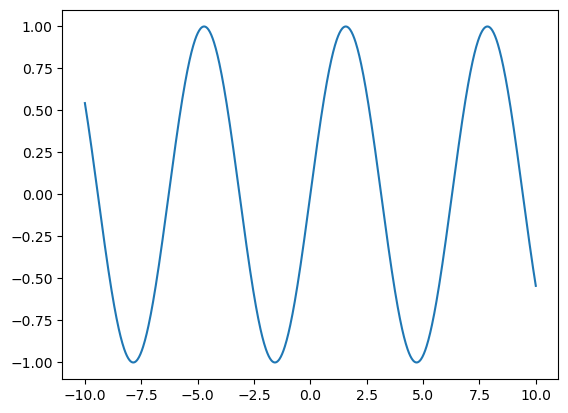

In [278]:
import numpy as np
import matplotlib.pyplot as plt # 以plt的形式导入是惯例
X = np.linspace(-10, 10, 1000)
y = np.sin(X) # 计算正弦值
plt.plot(X, y) # 绘制图表，使用plot实现点与点之间的平滑连接
plt.show() #  显示图表

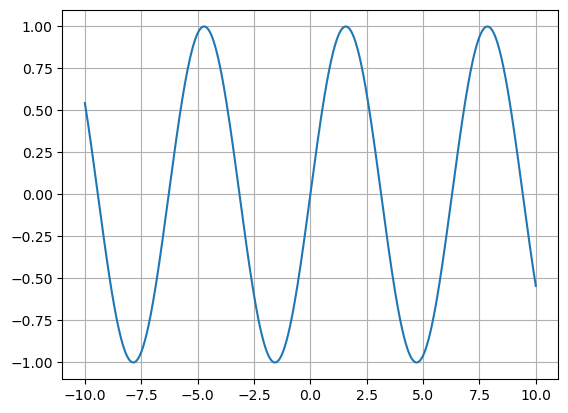

In [279]:
plt.grid(True)
plt.plot(X, y)
plt.show()

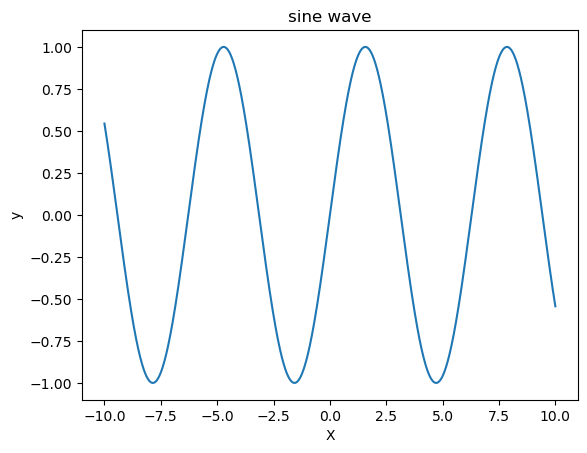

In [280]:
plt.title('sine wave')
plt.xlabel('X') #x轴的标签
plt.ylabel('y') # y轴的标签
plt.plot(X, y)
plt.show()

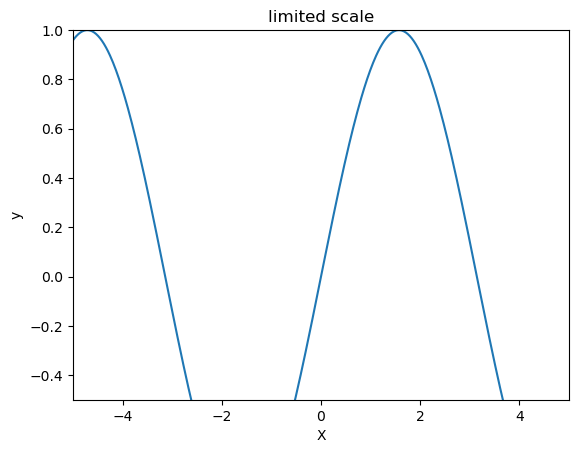

In [281]:
plt.xlim(-5,5) #  -5~5的范围
plt.ylim(-0.5, 1.0) # -0.5~1的范围
plt.plot(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('limited scale')
plt.show()

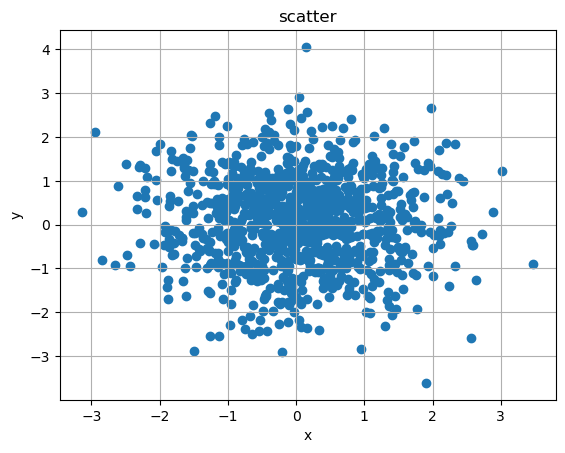

In [282]:
x = np.random.randn(1000) # 生成1000个服从标准正态分布的随机数
y = np.random.randn(1000)
plt.scatter(x, y)
plt.title('scatter')
plt.xlabel('x')
plt.ylabel('y')
plt.grid() #  即使不指定True，也会添加网格
plt.show()

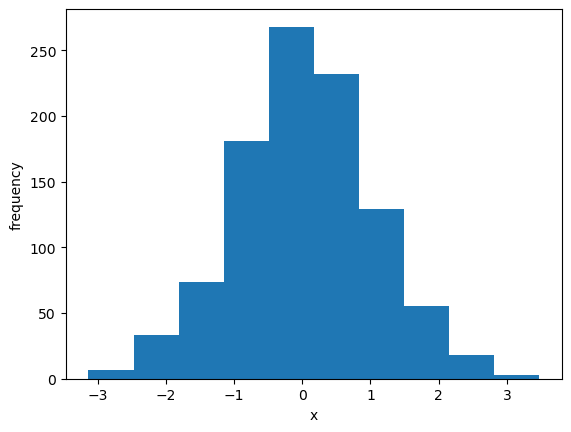

In [283]:
plt.hist(x) #  创建直方图
plt.xlabel('x')
plt.ylabel('frequency')
plt.show()

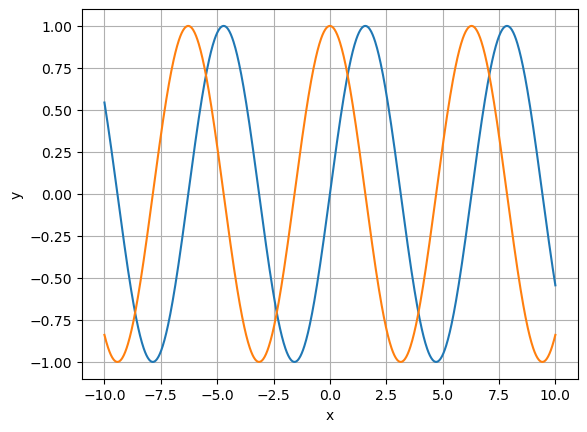

In [284]:
x = np.linspace(-10, 10, 1000)
y_1 = np.sin(x)
y_2 = np.cos(x)
plt.plot(x, y_1)
plt.plot(x, y_2)
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## 2.11 生成全零数组的函数

### 2.11.1 np.zeros

In [285]:
import numpy as np
np.zeros(10) #  创建一维数组
np.zeros(10, dtype=int) # 将数据类型指定为int
np.zeros((3, 4)) # 创建3×4的二维数组

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

### 2.11.2 np.empty与np.zeros的区别


In [286]:
def zeros():
    for i in range(10000):
        _ = np.zeros((1, i))

In [287]:
def empty():
    for i in range(10000):
        _ = np.empty((1, i))

In [288]:
%timeit zeros()

7.51 ms ± 70.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [289]:
%timeit empty()

2.37 ms ± 25 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## 2.12 生成全1数组的函数

### 2.12.1 np.ones


In [290]:
import numpy as np

In [291]:
np.ones(3) #  包含3个元素的一维数组

array([1., 1., 1.])

In [292]:
np.ones((2, 3)) #  2×3的二维数组

array([[1., 1., 1.],
       [1., 1., 1.]])

In [293]:
np.ones(4, dtype="float32") # 数据类型指定为float32

array([1., 1., 1., 1.], dtype=float32)

In [294]:
np.ones(4, dtype=np.int8) #  数据类型指定为int8。还可以使用在NumPy中预先定义好的对象进行指定

array([1, 1, 1, 1], dtype=int8)

In [295]:
np.ones((2,3), dtype="complex") # 还可以指定为复数形式

array([[1.+0.j, 1.+0.j, 1.+0.j],
       [1.+0.j, 1.+0.j, 1.+0.j]])

### 2.12.2 np.ones_like

In [296]:
a = np.array([[1, 2, 3],[2, 3, 4]])

In [297]:
a

array([[1, 2, 3],
       [2, 3, 4]])

In [298]:
np.ones_like(a)

array([[1, 1, 1],
       [1, 1, 1]])

In [299]:
b = np.array([2, 3, 4], dtype="int8" )

In [300]:
np.ones_like(b)

array([1, 1, 1], dtype=int8)

## 2.13 生成连续数列或等差数列的函数

### 2.13.1　Python的range函数


```bash
［终端窗口］
$ python
>>>[x for x in range(10)]

>>>import numpy as np
>>>np.array(range(10))
```

In [301]:
[x for x in range(10)]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [302]:
import numpy as np
np.array(range(10))

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

### 2.13.3 np.arange

In [303]:
import numpy as np

In [304]:
np.arange(5) # 0～5的等差数列（但是作为参数，指定的5是不包含在数列中的）

array([0, 1, 2, 3, 4])

In [305]:
np.arange(-10) # 指定负数，就会返回没有元素的数组

array([], dtype=int64)

In [306]:
np.arange(4.5) #  即使指定的是float型，也会生成数组

array([0., 1., 2., 3., 4.])

In [307]:
np.arange(1, 8)

array([1, 2, 3, 4, 5, 6, 7])

In [308]:
np.arange(2, 10)

array([2, 3, 4, 5, 6, 7, 8, 9])

In [309]:
np.arange(0.5, 5.5) # 使用带小数点的值进行设置也可以生成数组

array([0.5, 1.5, 2.5, 3.5, 4.5])

In [310]:
np.arange(0.55, 5.55)

array([0.55, 1.55, 2.55, 3.55, 4.55])

In [311]:
np.arange(2, 12, 2) # 首项为2、公差为2、终点为12的等差数列

array([ 2,  4,  6,  8, 10])

In [312]:
np.arange(2, 5, 0.2) #  公差可以不是整数

array([2. , 2.2, 2.4, 2.6, 2.8, 3. , 3.2, 3.4, 3.6, 3.8, 4. , 4.2, 4.4,
       4.6, 4.8])

In [313]:
np.arange(5, 2, -1) # 公差可以指定为负数

array([5, 4, 3])

In [314]:
np.arange(stop=3, step=1) # 如果不指定start，就会发生运行时错误

array([0, 1, 2])

In [315]:
np.arange(5, dtype='float64') # 变换成浮点型

array([0., 1., 2., 3., 4.])

In [316]:
np.arange(5.0, dtype='int') # 变换成整数型

array([0, 1, 2, 3, 4])

In [317]:
np.arange(0, 5, 0.5, dtype='int') #  公差中如果出现了小数，小数点后面的部分会被忽略

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [318]:
np.arange(0, 5, 1.5, dtype='int') # 与上面一样，出现了小数，小数点后面的部分会被忽略

array([0, 1, 2, 3])

## 2.14 生成线性等距数列的函数

### 2.14.1 np.linspace

In [319]:
import numpy as np

In [320]:
np.linspace(0, 1) # 首先指定起点为0，终点为1

array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
       0.10204082, 0.12244898, 0.14285714, 0.16326531, 0.18367347,
       0.20408163, 0.2244898 , 0.24489796, 0.26530612, 0.28571429,
       0.30612245, 0.32653061, 0.34693878, 0.36734694, 0.3877551 ,
       0.40816327, 0.42857143, 0.44897959, 0.46938776, 0.48979592,
       0.51020408, 0.53061224, 0.55102041, 0.57142857, 0.59183673,
       0.6122449 , 0.63265306, 0.65306122, 0.67346939, 0.69387755,
       0.71428571, 0.73469388, 0.75510204, 0.7755102 , 0.79591837,
       0.81632653, 0.83673469, 0.85714286, 0.87755102, 0.89795918,
       0.91836735, 0.93877551, 0.95918367, 0.97959184, 1.        ])

In [321]:
np.linspace(0, 49) #  注意是生成50个元素，宽度需要调整为1

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49.])

In [322]:
np.linspace(0, 2, 3) # 将0~2的区间分为3等分

array([0., 1., 2.])

In [323]:
np.linspace(0, -2, 3) # 使用负数也可以生成数组

array([ 0., -1., -2.])

In [324]:
np.linspace(0, 2, num=3) #  还可以指定num = 3

array([0., 1., 2.])

In [325]:
np.linspace(0, 2, num=3, endpoint=False) 

array([0.        , 0.66666667, 1.33333333])

In [326]:
np.linspace(0, 2, num=3, endpoint=True) # 返回元素中包含2的ndarray，这是默认设置

array([0., 1., 2.])

In [327]:
np.linspace(0, 1, retstep=True) # 显示公差

(array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
        0.10204082, 0.12244898, 0.14285714, 0.16326531, 0.18367347,
        0.20408163, 0.2244898 , 0.24489796, 0.26530612, 0.28571429,
        0.30612245, 0.32653061, 0.34693878, 0.36734694, 0.3877551 ,
        0.40816327, 0.42857143, 0.44897959, 0.46938776, 0.48979592,
        0.51020408, 0.53061224, 0.55102041, 0.57142857, 0.59183673,
        0.6122449 , 0.63265306, 0.65306122, 0.67346939, 0.69387755,
        0.71428571, 0.73469388, 0.75510204, 0.7755102 , 0.79591837,
        0.81632653, 0.83673469, 0.85714286, 0.87755102, 0.89795918,
        0.91836735, 0.93877551, 0.95918367, 0.97959184, 1.        ]),
 0.02040816326530612)

In [328]:
np.linspace(0, 2, num=3, retstep=True)

(array([0., 1., 2.]), 1.0)

In [329]:
np.linspace(0, 2, num=3, retstep=False) # 不显示公差（默认设置）

array([0., 1., 2.])

In [330]:
np.linspace(0, 2, num=3) # 不指定任何数据类型，就是float型

array([0., 1., 2.])

In [331]:
a = np.linspace(0, 1, 3)

In [332]:
a.dtype #  确认数据类型

dtype('float64')

In [333]:
np.linspace(0, 2, num=3, dtype='int') #  将数据类型指定为int型

array([0, 1, 2])

In [334]:
np.linspace(0, 1, num=4, dtype='float32') #  将数据类型指定为float32，就是32位浮点型

array([0.        , 0.33333334, 0.6666667 , 1.        ], dtype=float32)

In [335]:
np.linspace(0, 1, num=4, dtype='float64') #  将数据类型指定为float64，就是64位浮点型

array([0.        , 0.33333333, 0.66666667, 1.        ])

## 2.15 生成单位矩阵的函数

### 2.15.3 np.eye

In [336]:
import numpy as np

In [337]:
np.eye(3) #  3×3的单位矩阵

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [338]:
np.eye(10)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [339]:
np.eye(2, 3) # 2×3

array([[1., 0., 0.],
       [0., 1., 0.]])

In [340]:
np.eye(5, 4) # 5×4

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 0.]])

In [341]:
np.eye(5, k=0) # 若指定k=0，对角线上的元素不会移动

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

In [342]:
np.eye(5, k=1) #  向上方移动一个位置

array([[0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0.]])

In [343]:
np.eye(5, k=-1) # 向下方移动一个位置

array([[0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [344]:
np.eye(5, k=3) # 向上方移动3个位置

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [345]:
np.eye(5, dtype=int)

array([[1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1]])

In [346]:
np.eye(5, dtype=complex) # 指定为复数类型

array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]])

### 2.15.4 np.identity

In [347]:
np.identity(5) # 首先创建简单的矩阵

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

In [348]:
np.identity(2)

array([[1., 0.],
       [0., 1.]])

In [349]:
np.identity(3, dtype=int)

array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]])

In [350]:
np.identity(4, dtype="float32")

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]], dtype=float32)

In [351]:
%timeit np.eye(10000)

10.4 ms ± 320 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [352]:
%timeit np.identity(10000)

10.5 ms ± 737 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## 2.16 生成未初始化数组的函数

### 2.16.1 np.empty

In [353]:
import numpy as np

In [354]:
np.empty(10) # 未经初始化处理的一维数组

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [355]:
np.empty((2, 3)) #  2×3的二维数组

array([[1., 0., 0.],
       [0., 1., 0.]])

In [356]:
np.empty(5, dtype=np.int8) #将dtype指定为int8

array([0, 1, 1, 1, 1], dtype=int8)

In [358]:
np.empty(10, dtype=np.bool_) #  也可以指定为bool值

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [359]:
np.empty(10, dtype=complex) # 还可以生成复数

array([1.+0.j, 0.+0.j, 0.+1.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+1.j,
       0.+0.j, 0.+0.j])

### 2.16.2 与其他生成数组函数的对比

In [360]:
%timeit np.zeros(10000)

1.25 μs ± 17.5 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [361]:
%timeit np.empty(10000)

183 ns ± 8.82 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [362]:
%timeit np.ones(10000)

2.24 μs ± 6.25 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


## 2.17 随机数生成函数

### 2.17.1 　均匀随机数的生成

In [363]:
import numpy as np

In [364]:
np.random.rand() # 不设置任何数值，返回的就是一个数值

0.7822499567940059

In [365]:
np.random.randint(10) #返回0～9内的随机整数

2

In [366]:
np.random.rand(2,3) #  2×3的随机数数组

array([[0.64648169, 0.62099949, 0.47536387],
       [0.6095879 , 0.53712183, 0.10819512]])

In [367]:
np.random.randint(10, size=(2,3)) # 将数组的大小代入size中(默认设置为None)

array([[6, 7, 8],
       [5, 6, 5]])

In [368]:
np.random.randint(5,10, size=10) # 返回(5,10)内的随机整数

array([5, 6, 5, 7, 7, 8, 8, 5, 5, 8])

In [369]:
(10-5)*np.random.rand(10) + 5 # 返回(5,10)内的随机实数

array([6.04442185, 7.33220044, 9.92458668, 6.73925108, 6.5718568 ,
       9.8636847 , 5.77730208, 8.86801608, 8.06808908, 8.83911479])

### 2.17.2 随机数生成的固化

In [370]:
np.random.seed(seed=21) #  将seed设置为21

In [371]:
np.random.rand() # 生成一个随机数

0.04872488080912729

In [372]:
np.random.seed(21) # 再次将seed设置为21（即使不用参数指定seed，也可对seed进行设置）

In [373]:
np.random.rand() #返回同样的值

0.04872488080912729

In [374]:
np.random.seed(10) # 对于数组也可以进行同样的设置，将seed设置为10

In [375]:
np.random.rand(20) #生成20个随机数

array([0.77132064, 0.02075195, 0.63364823, 0.74880388, 0.49850701,
       0.22479665, 0.19806286, 0.76053071, 0.16911084, 0.08833981,
       0.68535982, 0.95339335, 0.00394827, 0.51219226, 0.81262096,
       0.61252607, 0.72175532, 0.29187607, 0.91777412, 0.71457578])

In [376]:
np.random.seed(23) # 将seed设置为23

In [377]:
np.random.rand(20) # 生成20个随机数

array([0.51729788, 0.9469626 , 0.76545976, 0.28239584, 0.22104536,
       0.68622209, 0.1671392 , 0.39244247, 0.61805235, 0.41193009,
       0.00246488, 0.88403218, 0.88494754, 0.30040969, 0.58958187,
       0.97842692, 0.84509382, 0.06507544, 0.29474446, 0.28793444])

In [378]:
np.random.seed(10) # 再将seed设置为10进行确认

In [379]:
np.random.rand(20) #  返回同样的值

array([0.77132064, 0.02075195, 0.63364823, 0.74880388, 0.49850701,
       0.22479665, 0.19806286, 0.76053071, 0.16911084, 0.08833981,
       0.68535982, 0.95339335, 0.00394827, 0.51219226, 0.81262096,
       0.61252607, 0.72175532, 0.29187607, 0.91777412, 0.71457578])

In [380]:
np.random.seed(23) #  同样地，再将seed设置为23进行确认

In [381]:
np.random.rand(20) # 返回同样的值

array([0.51729788, 0.9469626 , 0.76545976, 0.28239584, 0.22104536,
       0.68622209, 0.1671392 , 0.39244247, 0.61805235, 0.41193009,
       0.00246488, 0.88403218, 0.88494754, 0.30040969, 0.58958187,
       0.97842692, 0.84509382, 0.06507544, 0.29474446, 0.28793444])

### 2.17.3 列表的随机提取

In [382]:
a = ['Python', 'Ruby', 'Java', 'JavaScript', 'PHP'] #  创建一个列表

In [383]:
np.random.choice(a, 3) # 从列表a中随机提取3个元素

array(['PHP', 'JavaScript', 'JavaScript'], dtype='<U10')

In [384]:
np.random.choice(a, 5, replace=False) # 不重复提取

array(['Python', 'Ruby', 'JavaScript', 'Java', 'PHP'], dtype='<U10')

In [385]:
np.random.choice(a, 20, p = [0.8, 0.05, 0.05, 0.05, 0.05]) #通过将列表传递给p改变提取数值的频率。需要注意p中数值合计为1

array(['Python', 'Python', 'Python', 'Java', 'Python', 'Ruby', 'Python',
       'Python', 'Python', 'Python', 'Python', 'Ruby', 'Python', 'Python',
       'Python', 'Python', 'Python', 'Python', 'Python', 'Python'],
      dtype='<U10')

In [386]:
np.random.choice(5, 10) #  将整数传递给最初的元素，就等同于返回的是使用np.arange(5)生成的列表。这种情况下，会生成(0～5)内的10个随机整数

array([3, 4, 3, 0, 0, 4, 4, 3, 1, 1])

### 2.17.4 列表的随机排序

In [387]:
a = np.arange(10)

In [388]:
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [389]:
np.random.shuffle(a) # 对列表a中元素的顺序进行调换

In [390]:
a # 确认列表a中的元素

array([3, 9, 6, 2, 7, 0, 8, 1, 5, 4])

### 2.17.5 生成服从特定概率分布的随机数

In [391]:
np.random.randn() # 不指定任何参数，返回的就是单独的数值

1.3329211515002668

In [392]:
np.random.normal() # 这里也是同样返回单独的数值

-0.3940443571718848

In [393]:
np.random.randn(10) # 返回一维数组

array([-2.50408469, -1.37373969,  1.13563154, -0.43091352, -1.10028295,
        0.19820952,  0.0407598 ,  0.78145406,  0.06493754, -0.15102838])

In [394]:
np.random.normal(loc=1,scale=2.0, size=10) # loc为平均值，scale为标准差，size为所返回数组的大小

array([ 0.96796695,  4.01450161, -2.20965065,  4.57232069,  0.52723839,
       -3.85119192, -2.27477139, -0.40270012,  2.76283227,  1.69201825])

In [395]:
np.random.normal(size=10) # 返回的是与randn(10)相同的执行结果

array([ 0.08442389,  0.15584683,  0.9601634 , -0.70860884, -0.65790151,
       -0.2970833 ,  1.65759749,  0.35983817, -0.02306523, -1.9436952 ])

In [396]:
np.random.binomial(100, 0.5, 30) # 在(n, p) = (100, 0.5)中事件发生的次数。将此操作执行30次

array([52, 50, 58, 44, 49, 48, 37, 54, 46, 57, 57, 48, 49, 52, 55, 51, 55,
       48, 50, 49, 48, 43, 53, 52, 54, 42, 47, 51, 49, 47])

In [397]:
np.random.beta(1, 2, size=10) #  生成服从(α, β) = (1,2)的贝塔分布的10个随机数

array([0.18924402, 0.35652008, 0.12351546, 0.76978628, 0.21384202,
       0.52553931, 0.00662827, 0.07527514, 0.13934092, 0.21633758])

In [398]:
np.random.gamma(2, 2, size=10) # 生成服从(shape, scale) = (α, β) = (2,2)分布的随机数

array([ 3.60762785,  5.61167334,  4.29304449,  3.30809358,  5.25168067,
        2.9034974 , 11.39041276,  2.00128597,  1.91485218,  1.91253417])

In [399]:
np.random.poisson(2, 10) #  生成服从λ =2.0，size = 10 分布的随机数数组

array([1, 3, 2, 4, 3, 6, 3, 2, 4, 5])

In [400]:
np.random.poisson(2, (2,2)) # 还可以生成二维数组

array([[3, 3],
       [3, 2]])

In [401]:
np.random.chisquare(2, 10) # 生成自由度为2的10个值

array([5.7828752 , 1.70995986, 0.59956938, 1.01188615, 1.51083264,
       0.12579603, 1.32203305, 3.14030707, 0.38077057, 0.28068502])

In [402]:
from matplotlib import pyplot as plt

In [403]:
def standard_normal_distribution(x):
    return (1/np.sqrt(2*np.pi))*np.exp(-x**2/2)*1000 # 将服从标准正态分布的概率密度函数放大1000倍。
# (由于直方图度数的宽度为0.01，所以只放大数据数量的1/100倍)

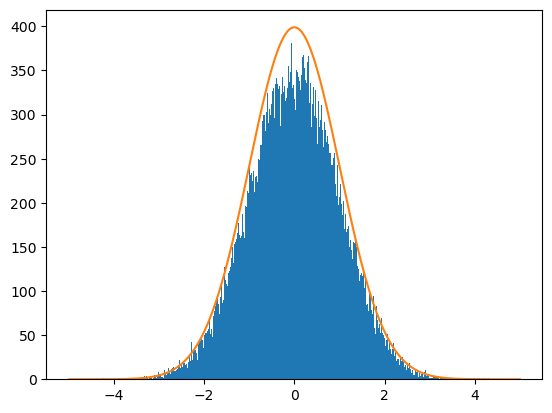

In [407]:
a = np.random.randn(100000) # 生成10万个服从标准正态分布的随机数
x = np.linspace(-5, 5, 1000)
plt.hist(a, bins=1000)
plt.plot(x, standard_normal_distribution(x))
plt.show()

## 2.18 数组的扁平化函数

### 2.18.1 numpy.ndarray.flatten

In [408]:
import numpy as np

In [409]:
a = np.arange(10).reshape(2, 5) # 生成2×5的二维数组

In [410]:
a

array([[0, 1, 2, 3, 4],
       [5, 6, 7, 8, 9]])

In [411]:
b = a.flatten() # 将转换后的一维数组代入b中

In [412]:
a # a本身并不会产生变化

array([[0, 1, 2, 3, 4],
       [5, 6, 7, 8, 9]])

In [413]:
b # b中代入的是转换后的数组

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [415]:
a.shape # 对shape进行确认

(2, 5)

In [416]:
b.shape # 由于b的shape是一维数组，所以只会显示一个数值

(10,)

In [417]:
c = np.arange(12).reshape(2, 2, 3) #  对三维数组进行确认

In [418]:
c

array([[[ 0,  1,  2],
        [ 3,  4,  5]],

       [[ 6,  7,  8],
        [ 9, 10, 11]]])

In [420]:
d = c.flatten() # 将转换后的一维数组代入d中

In [421]:
d

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [422]:
c.shape # 在这里也对c和d的shape进行确认

(2, 2, 3)

In [423]:
d.shape

(12,)

### 2.18.2 性能评估

In [425]:
arr = np.repeat(5, 10000).reshape(250, 40)

In [427]:
%timeit arr.flatten()

1.95 μs ± 25.2 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [428]:
%timeit np.ravel(arr)

285 ns ± 0.755 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


## 2.19 文本文件的读写函数

### 2.19.5 np.savetxt

In [429]:
import numpy as np

In [430]:
a = np.random.randn(3, 4) #  生成由服从标准正态分布的随机数所组成的二维数组

In [431]:
np.savetxt('sample1.txt', a) # 在不做任何指定的情况下对其进行保存

In [432]:
b = np.loadtxt('sample1.txt') #  载入保存后的数据

In [434]:
a

array([[ 0.21054886, -0.91832807,  1.84261422,  0.53120419],
       [-1.17748922, -1.64587721, -0.09331291,  0.60157858],
       [-0.88999885, -0.74577267,  0.63278933,  0.46697564]])

In [435]:
b

array([[ 0.21054886, -0.91832807,  1.84261422,  0.53120419],
       [-1.17748922, -1.64587721, -0.09331291,  0.60157858],
       [-0.88999885, -0.74577267,  0.63278933,  0.46697564]])

In [436]:
np.savetxt('sample1.csv', a) # 也可以保存为csv格式

In [437]:
c = np.loadtxt('sample1.csv')

In [438]:
c

array([[ 0.21054886, -0.91832807,  1.84261422,  0.53120419],
       [-1.17748922, -1.64587721, -0.09331291,  0.60157858],
       [-0.88999885, -0.74577267,  0.63278933,  0.46697564]])

In [439]:
np.savetxt('sample1.dat', a) #还可以保存为dat格式

In [440]:
d = np.loadtxt('sample1.dat')

In [441]:
d

array([[ 0.21054886, -0.91832807,  1.84261422,  0.53120419],
       [-1.17748922, -1.64587721, -0.09331291,  0.60157858],
       [-0.88999885, -0.74577267,  0.63278933,  0.46697564]])

In [442]:
np.savetxt('sample2.txt', a, delimiter=',')

In [443]:
e = np.loadtxt('sample2.txt') # delimiter中如果不做任何指定，会发生运行时错误

ValueError: could not convert string '2.105488643309341712e-01,-9.183280658130933416e-01,1.842614220254599866e+00,5.312041858446081566e-0 to float64 at row 0, column 1.

In [444]:
e = np.loadtxt('sample2.txt', delimiter=',')

In [445]:
e

array([[ 0.21054886, -0.91832807,  1.84261422,  0.53120419],
       [-1.17748922, -1.64587721, -0.09331291,  0.60157858],
       [-0.88999885, -0.74577267,  0.63278933,  0.46697564]])

In [446]:
np.savetxt('sample3.txt', a, fmt ='%.2e')

In [447]:
np.savetxt('sample4.txt', a, fmt ='%.2f')

In [448]:
f = np.array([[10.1+3.21j,100.0+32.1j],[20.0+0.2j,22.1-1j]]) # 生成将复数作为元素的数组

In [449]:
f

array([[ 10.1 +3.21j, 100. +32.1j ],
       [ 20.  +0.2j ,  22.1 -1.j  ]])

In [450]:
np.savetxt('sample5.txt', f, fmt=['%.3e+%.3ej', '%.1e+%.1ej'])

In [451]:
np.loadtxt('sample4.txt', usecols=(0,2)) #  只使用第0列和第2列

array([[ 0.21,  1.84],
       [-1.18, -0.09],
       [-0.89,  0.63]])

In [452]:
np.loadtxt('sample4.txt', skiprows=1) #  跳过第0行

array([[-1.18, -1.65, -0.09,  0.6 ],
       [-0.89, -0.75,  0.63,  0.47]])

In [453]:
np.savetxt('sample6.txt', a, fmt='%.3e', header='this is a header',footer='this is a footer')

In [454]:
np.savetxt('sample7.txt', a, fmt='%.3e', header='this is a header',footer='this is a footer', comments='>>>')

In [455]:
np.loadtxt('sample7.txt', comments='>>>') # 确认loadtxt是否准确读取文件

array([[ 0.2105 , -0.9183 ,  1.843  ,  0.5312 ],
       [-1.177  , -1.646  , -0.09331,  0.6016 ],
       [-0.89   , -0.7458 ,  0.6328 ,  0.467  ]])

In [457]:
np.loadtxt('foo.csv', dtype=[('col1', 'i8'), ('col2', 'S10'), ('col3', 'f8'), ('col4', 'S10')]) # 按照8字节的int型、10字节的string型, 8字节的float型,10
# 字节的string型的顺序进行指定

array([(18, b'female', 154.1, b'No'), (21, b'male', 172.3, b'Yes'),
       (22, b'female', 160.8, b'Yes'), (23, b'male', 180.1, b'Yes'),
       (25, b'female', 145. , b'No')],
      dtype=[('col1', '<i8'), ('col2', 'S10'), ('col3', '<f8'), ('col4', 'S10')])

In [458]:
np.loadtxt('foo.csv', dtype=[('col1', 'i8'), ('col2', 'S10'), ('col3','f8'), ('col4', 'S10')], unpack=True) #  指定unpack=True可以进行转置

[array([18, 21, 22, 23, 25]),
 array([b'female', b'male', b'female', b'male', b'female'], dtype='|S10'),
 array([154.1, 172.3, 160.8, 180.1, 145. ]),
 array([b'No', b'Yes', b'Yes', b'Yes', b'No'], dtype='|S10')]

In [459]:
age, gender, tall, driver_lisense=np.loadtxt('foo.csv', dtype=[('col1', 'i8'), ('col2', 'S10'), ('col3', 'f8'), ('col4', 'S10')], unpack=True)

In [460]:
age

array([18, 21, 22, 23, 25])

In [461]:
gender

array([b'female', b'male', b'female', b'male', b'female'], dtype='|S10')

In [462]:
tall

array([154.1, 172.3, 160.8, 180.1, 145. ])

In [463]:
driver_lisense

array([b'No', b'Yes', b'Yes', b'Yes', b'No'], dtype='|S10')

In [475]:
def driver_lisense(str): # 对两个函数进行定义
    if str == b'Yes' : return 1
    else: return -1

In [476]:
def gender(str):
    if str == b'male': return 1
    else: return -1

In [477]:
np.loadtxt('foo.csv', converters={1: lambda s: gender(s), 3: lambda s: driver_lisense(s)}) # 使用函数将字符串中的数据转换成数值

array([[ 18. ,  -1. , 154.1,  -1. ],
       [ 21. ,   1. , 172.3,   1. ],
       [ 22. ,  -1. , 160.8,   1. ],
       [ 23. ,   1. , 180.1,   1. ],
       [ 25. ,  -1. , 145. ,  -1. ]])

In [478]:
def gender2(str): #  重新对函数进行设置
    if not str: return 0 #没有输入任何数值时，就会返回0

    elif str == b'male': return 1
    else: return -1

In [482]:
np.loadtxt('foo.csv', converters={1: lambda s: gender2(s), 3: lambda s: driver_lisense(s)}, delimiter=' ')

array([[ 18. ,  -1. , 154.1,  -1. ],
       [ 21. ,   1. , 172.3,   1. ],
       [ 22. ,  -1. , 160.8,   1. ],
       [ 23. ,   1. , 180.1,   1. ],
       [ 25. ,  -1. , 145. ,  -1. ]])